# Logistic Regression for Anomaly Detection

This notebook implements Logistic Regression to identify anomalous users in a recommender system dataset.

### Pipeline Overview
1. Load and inspect data
2. Build per-user feature vectors (pivot to user × item rating matrix)
3. Reduce dimensionality with TruncatedSVD (handles sparsity well)
4. Train Logistic Regression with class balancing
5. Evaluate with AUC, Precision, Recall, F1
6. Generate and save anomaly scores for submission

## 1. Imports & Data Loading

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, classification_report
)
import os

# Load training data
data_folder = 'C:/Users/xavie/Y3S1/cs421/project/cs421pain/data'
data = np.load(os.path.join(data_folder, "training_batch_with_labels.npz"))
X_raw = data["X"]   # shape: (n_interactions, 3) — [user_id, item_id, rating]
y_raw = data["y"]   # shape: (n_users, 2)  — [user_id, label]

print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")


Interactions : 177,346
Users        : 1100
Items        : 993
Anomalous    : 100
Normal       : 1000


## 2. Feature Engineering — Per-User Vectors

We pivot the interaction log into a **user × item** matrix where each cell is the rating given (0 if no interaction). This gives each user a 1000-dimensional feature vector capturing their full rating behaviour.

In [38]:
# ── Build per-user feature matrix ──────────────────────────────────────────

interactions = pd.DataFrame(X_raw, columns=["user", "item", "rating"])
labels_df    = pd.DataFrame(y_raw, columns=["user", "label"])

# Pivot: rows = users, columns = items, values = rating (NaN → 0)
user_item = interactions.pivot_table(
    index="user", columns="item", values="rating", aggfunc="mean"
).fillna(0) # fill NA values with 0

# Align labels to the same user order
labels_df = labels_df.set_index("user").loc[user_item.index].reset_index()
y = labels_df["label"].values

print(f"User-item matrix shape : {user_item.shape}")
print(f"Label array shape      : {y.shape}")
print(f"Class balance          : {np.bincount(y)}  (normal, anomaly)")

# ── Additional handcrafted features ────────────────────────────────────────
# These capture high-level behavioural signals that anomalies may exhibit
item_means = interactions.groupby("item")["rating"].mean()
interactions["deviation"] = interactions["rating"] - interactions["item"].map(item_means)


agg = interactions.groupby("user").agg(
    num_ratings    = ("rating", "count"),
    mean_rating    = ("rating", "mean"),
    std_rating     = ("rating", "std"),
    num_items      = ("item",   "nunique"),
    pct_extreme    = ("rating", lambda r: ((r == 0) | (r == 5)).mean()),  # fraction of 0/5 ratings
    pct_zero       = ("rating", lambda r: (r == 0).mean()),
    pct_five       = ("rating", lambda r: (r == 5).mean()),
    # # Rating distribution shape
    # rating_skewness   = ("rating", lambda r: r.skew()), # 
    # rating_kurtosis   = ("rating", lambda r: r.kurtosis()),
    # median_rating     = ("rating", "median"),

    # # Item concentration — anomalies often target a narrow set of items
    # item_entropy      = ("item", lambda x: -(pd.Series(x.value_counts(normalize=True))
    #                                           * np.log2(pd.Series(x.value_counts(normalize=True)) + 1e-9)).sum()),

    # item-deviation features
    mean_deviation = ("deviation", "mean"),
    std_deviation  = ("deviation", "std"),
    abs_deviation  = ("deviation", lambda x: x.abs().mean()),
).fillna(0)

# Reindex to match user_item order
agg = agg.loc[user_item.index]

print("\nHandcrafted features:")
print(agg.head())

User-item matrix shape : (1100, 993)
Label array shape      : (1100,)
Class balance          : [1000  100]  (normal, anomaly)

Handcrafted features:
      num_ratings  mean_rating  std_rating  num_items  pct_extreme  pct_zero  \
user                                                                           
100            88     3.147727    1.169928         88     0.113636  0.045455   
101           231     3.406926    0.854016        231     0.095238  0.008658   
102            98     3.673469    1.072385         98     0.193878  0.000000   
103           103     3.000000    1.290994        103     0.126214  0.058252   
104            89     3.719101    0.988442         89     0.235955  0.000000   

      pct_five  mean_deviation  std_deviation  abs_deviation  
user                                                          
100   0.068182       -0.340116       1.120334       0.852990  
101   0.086580        0.052775       0.745982       0.561699  
102   0.193878        0.349555       1

## 3. Dimensionality Reduction

The raw user-item matrix has up to 1000 columns. We use **TruncatedSVD** (a sparse-friendly PCA) to compress it into a lower-dimensional embedding, then concatenate the handcrafted features.

In [39]:
# ── Custom transformer: applies SVD to user-item block only ─────────────────
# The handcrafted features (mean_rating, pct_extreme, etc.) are already compact
# and meaningful — running SVD over them would corrupt their signal.
# This transformer splits the matrix, compresses only the user-item block,
# then re-concatenates the handcrafted columns unchanged.

N_HANDCRAFTED = agg.shape[1]  # number of handcrafted feature columns (7)

class SVDPlusHandcrafted(BaseEstimator, TransformerMixin):
    """Applies TruncatedSVD to the user-item block; passes handcrafted features through."""
    def __init__(self, n_components=30):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-N_HANDCRAFTED])  # fit on user-item block only
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-N_HANDCRAFTED])
        hand_part = X[:, -N_HANDCRAFTED:]     # handcrafted columns passed through
        return np.hstack([svd_part, hand_part])

# ── Combine raw user-item matrix + handcrafted features (NO SVD applied yet) ─
# SVD is now inside the pipeline so GridSearchCV can tune n_components
X_raw_combined = np.hstack([user_item.values, agg.values])

print(f"Raw combined feature matrix shape : {X_raw_combined.shape}")
print(f"  └─ user-item columns : {user_item.shape[1]}")
print(f"  └─ handcrafted cols  : {N_HANDCRAFTED}")


Raw combined feature matrix shape : (1100, 1003)
  └─ user-item columns : 993
  └─ handcrafted cols  : 10


## 4. Logistic Regression Model

Key design choices:
- **`class_weight='balanced'`** — automatically up-weights the rare anomaly class (100 vs 1000 users), preventing the model from ignoring anomalies.
- **StandardScaler** — logistic regression is sensitive to feature scale.
- **`solver='lbfgs'`** with L2 regularisation — stable for this size.
- **Stratified 5-fold CV** — preserves class ratio in each fold; gives reliable AUC estimates on an imbalanced dataset.

In [40]:
N_COMPONENTS = 30
pipeline = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),  # SVD inside pipeline — now tunable
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   class_weight="balanced",  # handles 10:1 imbalance
                   max_iter=1000,
                   solver="lbfgs",
                   C=0.01,
                   random_state=42
               ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# X_raw_combined is used from here on (replaces X_features)
y_scores_cv = cross_val_predict(
    pipeline, X_raw_combined, y,
    cv=cv, method="predict_proba"
)[:, 1]

y_pred_cv = (y_scores_cv >= 0.5).astype(int)

print("=== Cross-validated Performance ===")
print(f"AUC       : {roc_auc_score(y, y_scores_cv):.4f}")
print(f"Precision : {precision_score(y, y_pred_cv):.4f}")
print(f"Recall    : {recall_score(y, y_pred_cv):.4f}")
print(f"F1        : {f1_score(y, y_pred_cv):.4f}")
print()
print(classification_report(y, y_pred_cv, target_names=["Normal", "Anomaly"]))


=== Cross-validated Performance ===
AUC       : 0.8718
Precision : 0.3151
Recall    : 0.6900
F1        : 0.4326

              precision    recall  f1-score   support

      Normal       0.96      0.85      0.90      1000
     Anomaly       0.32      0.69      0.43       100

    accuracy                           0.84      1100
   macro avg       0.64      0.77      0.67      1100
weighted avg       0.91      0.84      0.86      1100



## 5. ROC Curve

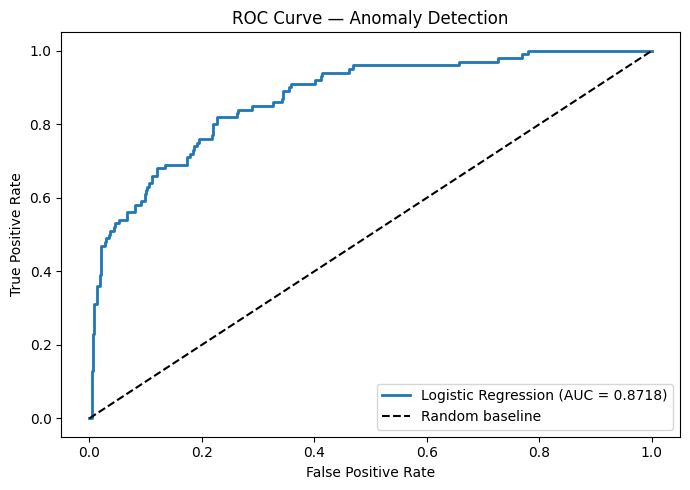

In [41]:
fpr, tpr, thresholds = roc_curve(y, y_scores_cv)
auc = roc_auc_score(y, y_scores_cv)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

C:\Users\xavie\AppData\Local\Temp\ipykernel_31248\4147591953.py:38: RuntimeWarning: invalid value encountered in divide
  2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),


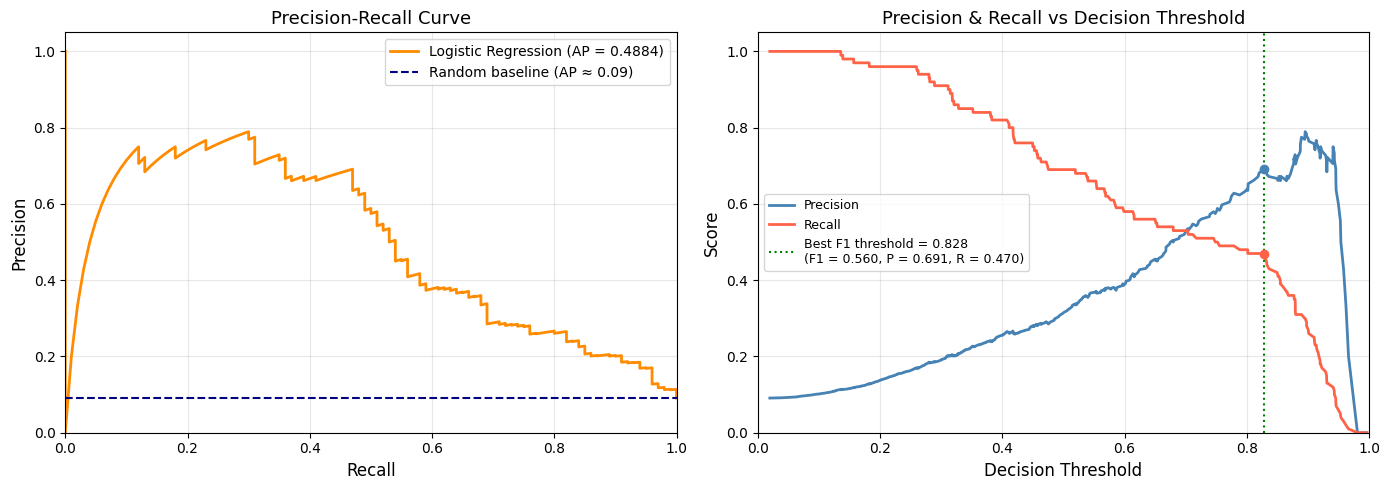

Average Precision (AP)  : 0.4884
Random baseline AP      : 0.0909  (= anomaly prevalence)
Improvement over random : 5.4x

Best F1 threshold : 0.828
  Precision       : 0.6912
  Recall          : 0.4700
  F1              : 0.5595


In [42]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)

# ── Compute PR curve from cross-validated scores ────────────────────────────
# y_scores_cv and y must already exist from the logistic regression notebook
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = y.mean()   # a random classifier sits at this precision level

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full PR curve ---
ax = axes[0]
ax.plot(recall_vals, precision_vals, lw=2, color="darkorange",
        label=f"Logistic Regression (AP = {ap:.4f})")
ax.axhline(baseline, color="navy", linestyle="--",
           label=f"Random baseline (AP ≈ {baseline:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Right: Precision & Recall vs Threshold ---
ax2 = axes[1]
ax2.plot(thresholds, precision_vals[:-1], lw=2, color="steelblue",  label="Precision")
ax2.plot(thresholds, recall_vals[:-1],    lw=2, color="tomato",     label="Recall")

# Mark F1-optimal threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

ax2.axvline(best_thresh, color="green", linestyle=":", lw=1.5,
            label=f"Best F1 threshold = {best_thresh:.3f}\n(F1 = {best_f1:.3f}, "
                  f"P = {precision_vals[best_idx]:.3f}, R = {recall_vals[best_idx]:.3f})")
ax2.scatter([best_thresh], [precision_vals[best_idx]], color="steelblue", zorder=5)
ax2.scatter([best_thresh], [recall_vals[best_idx]],    color="tomato",    zorder=5)

ax2.set_xlabel("Decision Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Precision & Recall vs Decision Threshold", fontsize=13)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision (AP)  : {ap:.4f}")
print(f"Random baseline AP      : {baseline:.4f}  (= anomaly prevalence)")
print(f"Improvement over random : {ap / baseline:.1f}x")
print()
print(f"Best F1 threshold : {best_thresh:.3f}")
print(f"  Precision       : {precision_vals[best_idx]:.4f}")
print(f"  Recall          : {recall_vals[best_idx]:.4f}")
print(f"  F1              : {best_f1:.4f}")

In [43]:
# ── Sample the curve at fixed recall levels ─────────────────────────────────
sample_recalls = np.linspace(0, 1, 11)   # 0.0, 0.1, ..., 1.0

rows = []
for target_r in sample_recalls:
    # Find index where recall is closest to the target
    idx = np.argmin(np.abs(recall_vals - target_r))
    thresh = thresholds[idx] if idx < len(thresholds) else 1.0
    rows.append({
        "Recall (target)" : f"{target_r:.1f}",
        "Recall (actual)" : f"{recall_vals[idx]:.4f}",
        "Precision"       : f"{precision_vals[idx]:.4f}",
        "Threshold"       : f"{thresh:.4f}",
    })

pr_table = pd.DataFrame(rows)
print(pr_table.to_string(index=False))

Recall (target) Recall (actual) Precision Threshold
            0.0          0.0000    0.0000    0.9810
            0.1          0.1000    0.7143    0.9434
            0.2          0.2000    0.7407    0.9181
            0.3          0.3000    0.7692    0.8947
            0.4          0.4000    0.6667    0.8549
            0.5          0.5000    0.5747    0.7486
            0.6          0.6000    0.3774    0.5842
            0.7          0.7000    0.2881    0.4740
            0.8          0.8000    0.2606    0.4112
            0.9          0.9000    0.2004    0.3117
            1.0          1.0000    0.0909    0.0197


In [44]:
# ── Export Performance Results to Excel (append mode) ────────────────────────
import os, openpyxl
from datetime import datetime
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report
)

EXCEL_PATH = 'performance_results.xlsx'
RUN_DESC = 'testing item-deviation features'

# ── Styles ───────────────────────────────────────────────────────────────────
HEADER_FILL  = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
SECTION_FILL = PatternFill('solid', start_color='BDD7EE', end_color='BDD7EE')
ALT_FILL     = PatternFill('solid', start_color='DEEAF1', end_color='DEEAF1')
RUN_FILL     = PatternFill('solid', start_color='E2EFDA', end_color='E2EFDA')
HEADER_FONT  = Font(name='Arial', bold=True, color='FFFFFF',  size=11)
SECTION_FONT = Font(name='Arial', bold=True, color='1F4E79',  size=10)
RUN_FONT     = Font(name='Arial', bold=True, color='375623',  size=10)
BODY_FONT    = Font(name='Arial', size=10)
CENTER = Alignment(horizontal='center', vertical='center')
LEFT   = Alignment(horizontal='left',   vertical='center')
thin   = Side(style='thin', color='9DC3E6')
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header(cell, text):
    cell.value = text; cell.font = HEADER_FONT; cell.fill = HEADER_FILL
    cell.alignment = CENTER; cell.border = BORDER

def style_section(cell, text):
    cell.value = text; cell.font = SECTION_FONT; cell.fill = SECTION_FILL
    cell.alignment = LEFT; cell.border = BORDER

def style_body(cell, value, alt=False, num_fmt='0.0000'):
    cell.value = value; cell.font = BODY_FONT
    cell.fill = ALT_FILL if alt else PatternFill(fill_type=None)
    cell.alignment = CENTER; cell.border = BORDER
    if isinstance(value, float): cell.number_format = num_fmt

def style_run_header(cell, text):
    cell.value = text; cell.font = RUN_FONT; cell.fill = RUN_FILL
    cell.alignment = LEFT; cell.border = BORDER

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

def next_append_row(ws):
    """First empty row after existing content, with one blank gap."""
    return (ws.max_row + 2) if ws.max_row > 0 else 1

# ── Timestamp & config ───────────────────────────────────────────────────────
run_ts    = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
lr_C      = float(pipeline.named_steps['lr'].C)
run_label_short = f'Run {{run_num}}'  # filled below once run_num known

# ── Load or create workbook ───────────────────────────────────────────────────
if os.path.exists(EXCEL_PATH):
    wb = openpyxl.load_workbook(EXCEL_PATH)
else:
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

existing_cv = [s for s in wb.sheetnames if s == 'CV Performance']
run_num = 1
if 'CV Performance' in wb.sheetnames:
    ws_check = wb['CV Performance']
    # count data rows (skip header row 1)
    run_num = sum(
        1 for row in ws_check.iter_rows(min_row=2, max_col=1)
        if row[0].value is not None
    ) + 1

run_header_text = (
    f'Run {run_num}  |  {run_ts}  '
    f'|  C={lr_C}  |  SVD components={N_COMPONENTS}'
)

# ── Recompute metrics ─────────────────────────────────────────────────────────
auc_val  = roc_auc_score(y, y_scores_cv)
prec_val = precision_score(y, y_pred_cv)
rec_val  = recall_score(y, y_pred_cv)
f1_val   = f1_score(y, y_pred_cv)
report   = classification_report(
    y, y_pred_cv, target_names=['Normal', 'Anomaly'], output_dict=True
)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_scores_cv)
ap       = average_precision_score(y, y_scores_cv)
baseline = float(y.mean())
f1_scores_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_pr_idx = int(np.argmax(f1_scores_pr))
best_thresh = float(pr_thresholds[best_pr_idx])
best_f1_pr  = float(f1_scores_pr[best_pr_idx])

# ════════════════════════════════════════════════════════════════════════════
# SHEET 1 — CV Performance  (flat comparison table, one row per run)
# ════════════════════════════════════════════════════════════════════════════
CV_COLS = [
    ('Run',                  8,   '0',       lambda: run_num),
    ('Timestamp',           22,   '@',       lambda: run_ts),
    ('C (regularisation)',  20,   '0.####',  lambda: lr_C),
    ('SVD Components',      16,   '0',       lambda: N_COMPONENTS),
    ('AUC',                 10,   '0.0000',  lambda: auc_val),
    ('Precision @0.5',      14,   '0.0000',  lambda: prec_val),
    ('Recall @0.5',         13,   '0.0000',  lambda: rec_val),
    ('F1 @0.5',             10,   '0.0000',  lambda: f1_val),
    ('AP (PR curve)',        14,   '0.0000',  lambda: ap),
    ('Best-F1 Threshold',   18,   '0.0000',  lambda: best_thresh),
    ('Best-F1 Score',       14,   '0.0000',  lambda: best_f1_pr),
    ('Normal Precision',    16,   '0.0000',  lambda: report['Normal']['precision']),
    ('Normal Recall',       14,   '0.0000',  lambda: report['Normal']['recall']),
    ('Anomaly Precision',   17,   '0.0000',  lambda: report['Anomaly']['precision']),
    ('Anomaly Recall',      15,   '0.0000',  lambda: report['Anomaly']['recall']),
    ('Macro Avg Precision', 19,   '0.0000',  lambda: report['macro avg']['precision']),
    ('Macro Avg Recall',    17,   '0.0000',  lambda: report['macro avg']['recall']),
    ('Description',         40,   '@',       lambda: RUN_DESC),
]

if 'CV Performance' in wb.sheetnames:
    ws1 = wb['CV Performance']
    data_row = ws1.max_row + 1
else:
    ws1 = wb.create_sheet('CV Performance')
    data_row = 2

# Always (re)write headers in row 1 — ensures all columns are labelled
for col_i, (label, width, _, _fn) in enumerate(CV_COLS, 1):
    style_header(ws1.cell(1, col_i), label)
    ws1.column_dimensions[get_column_letter(col_i)].width = width
ws1.row_dimensions[1].height = 20

alt = (run_num % 2 == 0)
for col_i, (_label, _w, fmt, fn) in enumerate(CV_COLS, 1):
    style_body(ws1.cell(data_row, col_i), fn(), alt, num_fmt=fmt)

# ════════════════════════════════════════════════════════════════════════════
# SHEET 2 — ROC Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
ROC_COLS = [
    ('False Positive Rate', 22),
    ('True Positive Rate',  22),
    ('Threshold',           18),
    ('Notes',               36),
]

if 'ROC Curve' in wb.sheetnames:
    ws2 = wb['ROC Curve']
    r2  = next_append_row(ws2)
else:
    ws2 = wb.create_sheet('ROC Curve')
    for col_i, (_, w) in enumerate(ROC_COLS, 1):
        ws2.column_dimensions[get_column_letter(col_i)].width = w
    r2 = 1

ws2.merge_cells(f'A{r2}:D{r2}')
style_run_header(ws2.cell(r2, 1), run_header_text)
ws2.row_dimensions[r2].height = 18
for col_i, (label, _) in enumerate(ROC_COLS, 1):
    style_header(ws2.cell(r2+1, col_i), label)

n_points = min(len(fpr), 100)
roc_idx  = np.round(np.linspace(0, len(fpr)-1, n_points)).astype(int)
thresh_s = np.append(thresholds, np.nan)[roc_idx]

for offset, (fp, tp, th) in enumerate(zip(fpr[roc_idx], tpr[roc_idx], thresh_s)):
    ri  = r2 + 2 + offset
    alt = (offset % 2 == 1)
    style_body(ws2.cell(ri, 1), float(fp), alt)
    style_body(ws2.cell(ri, 2), float(tp), alt)
    style_body(ws2.cell(ri, 3), None if np.isnan(th) else float(th), alt)
    note = f'AUC={auc_val:.4f} — origin point (no threshold)' if offset == 0 else ''
    style_body(ws2.cell(ri, 4), note, alt, num_fmt='@')

# ════════════════════════════════════════════════════════════════════════════
# SHEET 3 — Precision-Recall Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
PR_COLS = [
    ('Recall',    16),
    ('Precision', 14),
    ('Threshold', 14),
    ('F1 Score',  12),
]

if 'Precision-Recall Curve' in wb.sheetnames:
    ws3 = wb['Precision-Recall Curve']
    r3  = next_append_row(ws3)
else:
    ws3 = wb.create_sheet('Precision-Recall Curve')
    for col_i, (_, w) in enumerate(PR_COLS, 1):
        ws3.column_dimensions[get_column_letter(col_i)].width = w
    r3 = 1

# Run header
ws3.merge_cells(f'A{r3}:D{r3}')
style_run_header(ws3.cell(r3, 1), run_header_text)
ws3.row_dimensions[r3].height = 18

# Summary line
ws3.merge_cells(f'A{r3+1}:D{r3+1}')
c_sum = ws3.cell(r3+1, 1)
c_sum.value = (
    f'AP={ap:.4f}  |  Baseline≈{baseline:.4f}  |  '
    f'Improvement {ap/baseline:.1f}x  |  '
    f'Best-F1 threshold={best_thresh:.3f} '
    f'(F1={best_f1_pr:.4f}, '
    f'P={precision_vals[best_pr_idx]:.4f}, '
    f'R={recall_vals[best_pr_idx]:.4f})'
)
c_sum.font = Font(name='Arial', size=9)
c_sum.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
ws3.row_dimensions[r3+1].height = 26

# Section A: Sampled table
SEC_A_COLS = [
    ('Recall (target)', 16),
    ('Recall (actual)', 16),
    ('Precision',       14),
    ('Threshold',       14),
]
ws3.merge_cells(f'A{r3+2}:D{r3+2}')
style_section(ws3.cell(r3+2, 1), 'Sampled PR Table — fixed recall levels 0.0 to 1.0')
for col_i, (label, _) in enumerate(SEC_A_COLS, 1):
    style_header(ws3.cell(r3+3, col_i), label)

for s_off, target_r in enumerate(np.linspace(0, 1, 11)):
    idx2  = int(np.argmin(np.abs(recall_vals - target_r)))
    th2   = float(pr_thresholds[idx2]) if idx2 < len(pr_thresholds) else 1.0
    row_i = r3 + 4 + s_off
    alt   = (s_off % 2 == 1)
    style_body(ws3.cell(row_i, 1), float(target_r), alt)
    style_body(ws3.cell(row_i, 2), float(recall_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 3), float(precision_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 4), th2, alt)

# Section B: Full curve (downsampled)
sb = r3 + 16
ws3.merge_cells(f'A{sb}:D{sb}')
style_section(ws3.cell(sb, 1), 'Full PR Curve — downsampled to 100 points')
for col_i, (label, _) in enumerate(PR_COLS, 1):
    style_header(ws3.cell(sb+1, col_i), label)

n_pts  = min(len(precision_vals)-1, 100)
pr_idx = np.round(np.linspace(0, len(precision_vals)-2, n_pts)).astype(int)
for p_off, pi in enumerate(pr_idx):
    ri  = sb + 2 + p_off
    alt = (p_off % 2 == 1)
    denom = precision_vals[pi] + recall_vals[pi]
    f1v   = float(2*precision_vals[pi]*recall_vals[pi]/denom) if denom > 0 else 0.0
    style_body(ws3.cell(ri, 1), float(recall_vals[pi]), alt)
    style_body(ws3.cell(ri, 2), float(precision_vals[pi]), alt)
    style_body(ws3.cell(ri, 3), float(pr_thresholds[pi]), alt)
    style_body(ws3.cell(ri, 4), f1v, alt)

# ── Save ─────────────────────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f'{EXCEL_PATH} updated — Run {run_num} appended ({run_ts})')


performance_results.xlsx updated — Run 2 appended (2026-03-18 13:36:32)


C:\Users\xavie\AppData\Local\Temp\ipykernel_31248\3142395269.py:93: RuntimeWarning: invalid value encountered in divide
  2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),


## 6. Anomaly Score Distribution

A well-trained model should separate the score distributions of normal vs anomalous users.

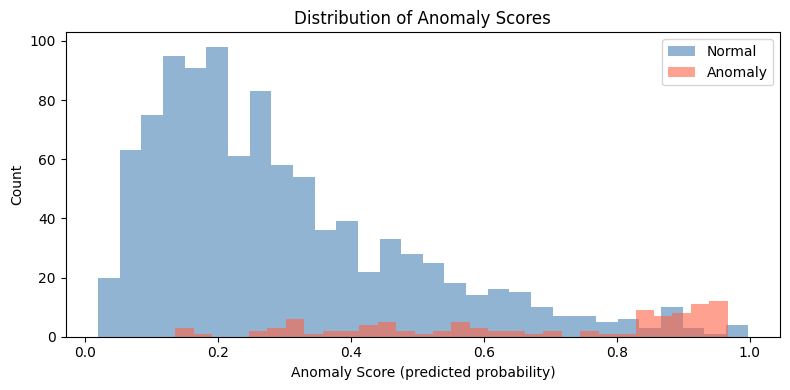

In [45]:
plt.figure(figsize=(8, 4))
plt.hist(y_scores_cv[y == 0], bins=30, alpha=0.6, label="Normal",   color="steelblue")
plt.hist(y_scores_cv[y == 1], bins=30, alpha=0.6, label="Anomaly",  color="tomato")
plt.xlabel("Anomaly Score (predicted probability)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train Final Model & Generate Submission

We refit on the full training set, then score the held-out test batch.

In [46]:
# ── Fit on ALL training data ────────────────────────────────────────────────
pipeline.fit(X_raw_combined, y)
print("Final model trained on full training set.")


Final model trained on full training set.


In [50]:
# ── Helper: build RAW combined features for any interaction batch ────────────
# Returns [user_item_matrix | handcrafted_features] — no SVD applied here.
# SVD is handled inside the pipeline automatically.

def build_features_raw(X_interactions, all_items):
    """
    Parameters
    ----------
    X_interactions : np.ndarray, shape (n, 3)  — [user_id, item_id, rating]
    all_items      : item index from training (ensures consistent column order)

    Returns
    -------
    X_combined : np.ndarray, shape (n_users, n_items + n_handcrafted)
    users      : list of user ids in row order
    """
    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])

    pivot = df.pivot_table(
        index="user", columns="item", values="rating", aggfunc="mean"
    ).reindex(columns=all_items, fill_value=0).fillna(0)

    item_means = interactions.groupby("item")["rating"].mean()
    interactions["deviation"] = interactions["rating"] - interactions["item"].map(item_means)

    agg_new = df.groupby("user").agg(
        num_ratings = ("rating", "count"),
        mean_rating = ("rating", "mean"),
        std_rating  = ("rating", "std"),
        num_items   = ("item",   "nunique"),
        pct_extreme = ("rating", lambda r: ((r == 0) | (r == 5)).mean()),
        pct_zero    = ("rating", lambda r: (r == 0).mean()),
        pct_five    = ("rating", lambda r: (r == 5).mean()),
        # item-deviation features
        mean_deviation = ("deviation", "mean"),
        std_deviation  = ("deviation", "std"),
        abs_deviation  = ("deviation", lambda x: x.abs().mean()),
        
    ).fillna(0).loc[pivot.index]

    return np.hstack([pivot.values, agg_new.values]), pivot.index.tolist()


# ── Score the test batch ──────────────────────────────────────────────────────
data_test  = np.load(os.path.join(data_folder, "first_batch.npz"))
X_test_raw = data_test["X"]

all_items = user_item.columns.tolist()  # item index from training

X_test_combined, test_users = build_features_raw(X_test_raw, all_items)

# Use best_pipeline if grid search was run, otherwise use pipeline
score_pipeline = best_pipeline if 'best_pipeline' in dir() else pipeline
anomaly_scores = score_pipeline.predict_proba(X_test_combined)[:, 1]

print(f"Scored {len(anomaly_scores)} users")
print(f"Score range  : [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score   : {anomaly_scores.mean():.4f}")

# ── Save submission ───────────────────────────────────────────────────────────
np.savez("submission_lr.npz", predictions=anomaly_scores)
print("\nsubmission_lr.npz saved!")


KeyError: "Label(s) ['deviation'] do not exist"

## 8. (Optional) Hyperparameter Tuning

Run this cell to search over regularisation strength `C` and SVD components. This can meaningfully improve AUC.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Search over both SVD dimensionality and regularisation strength.
# n_components is now tunable because SVDPlusHandcrafted sits inside the pipeline.
param_grid = {
    "svd_hc__n_components": [i for i in range (30, 160, 10)],
    "lr__C":                [0.001, 0.01, 0.1, 1.0],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True   # automatically refits best params on the full dataset
)

grid_search.fit(X_raw_combined, y)

print(f"Best n_components : {grid_search.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_search.best_params_['lr__C']}")
print(f"Best AUC          : {grid_search.best_score_:.4f}")

# Results table sorted by AUC
results = pd.DataFrame(grid_search.cv_results_)
print(results[
    ["param_svd_hc__n_components", "param_lr__C", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False).head(10).to_string(index=False))

# Use the best pipeline for all subsequent scoring
best_pipeline = grid_search.best_estimator_


Fitting 5 folds for each of 52 candidates, totalling 260 fits
Best n_components : 30
Best C            : 0.01
Best AUC          : 0.8739
 param_svd_hc__n_components  param_lr__C  mean_test_score  std_test_score
                         30        0.010          0.87385        0.023224
                         30        0.100          0.86975        0.019544
                         40        0.010          0.86920        0.019114
                         30        1.000          0.86775        0.017172
                         40        0.100          0.86600        0.017258
                         40        1.000          0.86145        0.013225
                         30        0.001          0.85995        0.026658
                         50        0.010          0.85950        0.026856
                         40        0.001          0.85755        0.023553
                         60        0.010          0.85240        0.027147
